In [ ]:
# 📌 Step 1: Imports
import sys
import os
sys.path.append(os.path.abspath('..'))  # Add parent directory to path
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from helpers import load_images_from_folder

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [2]:
# Load data
X, y, class_names = load_images_from_folder('../dataset/train')
X_test, y_test, _ = load_images_from_folder('../dataset/test')
print("Train shape:", X.shape, y.shape)
print("Test shape:", X_test.shape, y_test.shape)
print("Classes:", class_names)

Train shape: (3209, 128, 128, 3) (3209,)
Test shape: (880, 128, 128, 3) (880,)
Classes: ['Black_rot', 'Esca_(Black_Measles)', 'Healthy', 'Leaf_blight_(Isariopsis_Leaf_Spot)']


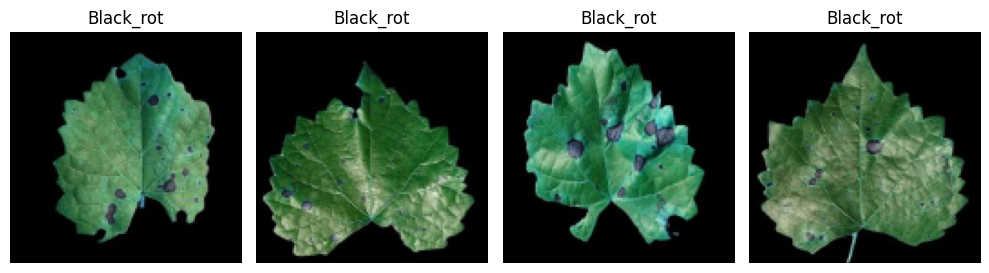

In [5]:
# 📌 Step 3: Visualize Sample Images
plt.figure(figsize=(10, 5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(X[i])
    plt.title(class_names[y[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [6]:
# 📌 Step 4: Train/Validation Split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape)


Train: (2567, 128, 128, 3) Val: (642, 128, 128, 3)


In [7]:
# 📌 Step 5: Define CNN Model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


c:\Users\avtka\Desktop\grape leaf cnn\grapEnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# 📌 Step 6: Train the Model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)


Epoch 1/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 26s 289ms/step - accuracy: 0.5173 - loss: 1.4487 - val_accuracy: 0.8474 - val_loss: 0.4143
Epoch 2/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 273ms/step - accuracy: 0.8159 - loss: 0.4461 - val_accuracy: 0.9190 - val_loss: 0.2560
Epoch 3/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 271ms/step - accuracy: 0.8826 - loss: 0.3123 - val_accuracy: 0.8162 - val_loss: 0.4390
Epoch 4/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 22s 276ms/step - accuracy: 0.9177 - loss: 0.2556 - val_accuracy: 0.8847 - val_loss: 0.2597
Epoch 5/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 27s 330ms/step - accuracy: 0.9506 - loss: 0.1421 - val_accuracy: 0.9393 - val_loss: 0.1614
Epoch 6/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 24s 302ms/step - accuracy: 0.9626 - loss: 0.1080 - val_accuracy: 0.9081 - val_loss: 0.2448
Epoch 7/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 279ms/step - accuracy: 0.9634 - loss: 0.1114 - val_accuracy: 0.9268 - val_loss: 0.2065
Epoch 8/10
81/81 ━━━━━━━━━━━━━━━━━━━━ 23s 283ms/step - accuracy: 0.9721 - loss: 0.0788 - val_accu

In [10]:
# 📌 Step 7: Save the Model
model.save('../models/CNN_model.keras')
print("✅ Model saved to models/cnn_model.keras")



✅ Model saved to models/cnn_model.keras


In [11]:
# 📌 Step 8: Evaluate on Test Set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")


28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.9276 - loss: 0.2326
Test Accuracy: 0.93


In [1]:
from tensorflow.python.client import device_lib
print(device_lib.list_local_devices())

[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 12233664203939312766
xla_global_id: -1
]
